# Children's Speech ASR — Whisper-tiny + LoRA Fine-tuning

This notebook fine-tunes `openai/whisper-tiny` with **Low-Rank Adaptation (LoRA)** using the
[PEFT](https://github.com/huggingface/peft) library. LoRA injects trainable rank-decomposition
matrices into selected attention projections, updating **< 1 % of total parameters** while
matching or exceeding full fine-tune quality on domain-shifted data.

```
W' = W + BA,   B ∈ R^{d×r},  A ∈ R^{r×k},  r ≪ min(d, k)
```

Evaluation metric: **Word Error Rate (WER)**.  
Comparison: zero-shot → LoRA fine-tuned, broken down by age bucket.

**GenAI statement**: Code assistance provided by Claude (Anthropic). All outputs were reviewed
and verified for technical accuracy by the student.

---
Dataset: https://www.drivendata.org/competitions/308/childrens-word-asr/page/980/

In [1]:
# Set cache directories (UCL lab machines)
import os
os.environ['HF_HOME']       = '/cs/student/project_msc/2025/dsml/nmxian/huggingface_cache'
os.environ['TORCH_HOME']    = '/cs/student/project_msc/2025/dsml/nmxian/torch_cache'
os.environ['KAGGLEHUB_CACHE'] = '/cs/student/project_msc/2025/dsml/nmxian/kaggle_cache'

In [2]:
# ── 0. Install required libraries ────────────────────────────────────────────
#!pip install -q transformers datasets soundfile librosa jiwer scikit-learn peft accelerate evaluate numpy pandas matplotlib

In [3]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, json, random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import soundfile as sf
import librosa
import jiwer

from torch.utils.data import Dataset
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

print(f"torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
import peft; print(f"peft        : {peft.__version__}")
import transformers; print(f"transformers: {transformers.__version__}")

torch       : 2.8.0+cu128
CUDA        : True
peft        : 0.17.1
transformers: 4.57.6


In [4]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
DATA_ROOT        = Path("/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2")
MODEL_NAME       = "openai/whisper-tiny"
SAMPLE_RATE      = 16_000
MAX_DURATION_SEC = 30.0

# Set to None to use full dataset
# NUM_TRAIN_SAMPLES = 5_000
# NUM_EVAL_SAMPLES  = 1_000
NUM_TRAIN_SAMPLES = None
NUM_EVAL_SAMPLES  = None

# LoRA hyper-parameters
LORA_R       = 16    # rank
LORA_ALPHA   = 32    # scaling factor; effective LR scale = alpha / r = 2
LORA_DROPOUT = 0.05
# Target the query and value projections in all attention layers
# (encoder self-attn, decoder self-attn, decoder cross-attn)
LORA_TARGET_MODULES = ["q_proj", "v_proj"]

BATCH_SIZE    = 16   # LoRA uses far less GPU memory → larger batch
LEARNING_RATE = 1e-3 # LoRA adapters accept higher LR than full fine-tune
NUM_EPOCHS    = 5
NUM_BEAMS     = 5    # beam search width for inference and eval
OUTPUT_DIR    = str(DATA_ROOT / "whisper_tiny_lora")
SEED          = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


In [5]:
# ── 3. Load speaker-independent splits ───────────────────────────────────────
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_raw = load_jsonl(DATA_ROOT / "train_word_transcripts_spkind.jsonl")
val_raw   = load_jsonl(DATA_ROOT / "val_word_transcripts_spkind.jsonl")
test_raw  = load_jsonl(DATA_ROOT / "test_word_transcripts_spkind.jsonl")

df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"\n{name} — {len(df):,} utterances")
    print(f"  Children   : {df['child_id'].nunique():,}")
    print(f"  Age dist   :\n{df['age_bucket'].value_counts().to_string()}")
    print(f"  Duration   : mean={df['audio_duration_sec'].mean():.1f}s  "
          f"max={df['audio_duration_sec'].max():.1f}s")

# Verify no child overlap between splits
train_ids = set(df_train["child_id"])
val_ids   = set(df_val["child_id"])
test_ids  = set(df_test["child_id"])
overlap_tv = train_ids & val_ids
overlap_tt = train_ids & test_ids
overlap_vt = val_ids   & test_ids
print(f"\nChild overlap — train∩val: {len(overlap_tv)}, "
      f"train∩test: {len(overlap_tt)}, val∩test: {len(overlap_vt)}")


train — 67,041 utterances
  Children   : 1,495
  Age dist   :
age_bucket
8-11    51945
5-7      8051
3-4      7045
  Duration   : mean=7.1s  max=1348.7s

val — 14,308 utterances
  Children   : 299
  Age dist   :
age_bucket
8-11    11091
5-7      1721
3-4      1496
  Duration   : mean=6.6s  max=78.0s

test — 14,223 utterances
  Children   : 381
  Age dist   :
age_bucket
8-11    10934
5-7      1718
3-4      1571
  Duration   : mean=6.6s  max=109.5s

Child overlap — train∩val: 0, train∩test: 0, val∩test: 0


In [6]:
# ── 4. Filter by duration ─────────────────────────────────────────────────────
def filter_duration(df, max_sec=MAX_DURATION_SEC):
    return df[df["audio_duration_sec"] <= max_sec].reset_index(drop=True)

df_train = filter_duration(df_train)
df_val   = filter_duration(df_val)
df_test  = filter_duration(df_test)

train_data = df_train.to_dict("records")
eval_data  = df_val.to_dict("records")
test_data  = df_test.to_dict("records")

if NUM_TRAIN_SAMPLES:
    train_data = train_data[:NUM_TRAIN_SAMPLES]
if NUM_EVAL_SAMPLES:
    eval_data = eval_data[:NUM_EVAL_SAMPLES]

print(f"Train : {len(train_data):,}")
print(f"Eval  : {len(eval_data):,}")
print(f"Test  : {len(test_data):,}")

Train : 65,337
Eval  : 14,079
Test  : 13,964


In [7]:
# ── 5. Audio utility ──────────────────────────────────────────────────────────
def load_audio(audio_path_rel: str) -> np.ndarray:
    path = DATA_ROOT / audio_path_rel
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio.astype(np.float32),
                                 orig_sr=sr, target_sr=SAMPLE_RATE)
    return audio.astype(np.float32)

In [8]:
# ── 6. Processor ──────────────────────────────────────────────────────────────
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language="English", task="transcribe"
)
print("Vocab size:", processor.tokenizer.vocab_size)

Vocab size: 50258


In [9]:
# ── 7. Dataset & collator (identical to whisper_tiny notebook) ───────────────
class WhisperSpeechDataset(Dataset):
    def __init__(self, records, processor):
        self.records   = records
        self.processor = processor

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item  = self.records[idx]
        audio = load_audio(item['audio_path'])
        feat  = self.processor.feature_extractor(
            audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        )
        input_features = feat.input_features.squeeze(0)
        labels = self.processor.tokenizer(
            item['orthographic_text'].lower(), return_tensors="pt"
        ).input_ids.squeeze(0)
        return {"input_features": input_features, "labels": labels}


@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: WhisperProcessor

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = torch.stack([f["input_features"] for f in features])
        label_list = [f["labels"] for f in features]
        max_len    = max(l.shape[0] for l in label_list)
        labels     = torch.full((len(label_list), max_len), -100, dtype=torch.long)
        for i, lbl in enumerate(label_list):
            labels[i, :lbl.shape[0]] = lbl
        return {"input_features": input_features, "labels": labels}

In [10]:
# ── 8. Load base model & apply LoRA ──────────────────────────────────────────
base_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Generation config (set before wrapping with PEFT)
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="english", task="transcribe"
)
base_model.config.forced_decoder_ids   = forced_decoder_ids
base_model.config.suppress_tokens      = []
base_model.config.use_cache            = False  # required for gradient checkpointing with LoRA
base_model.generation_config.language  = "english"
base_model.generation_config.task      = "transcribe"
base_model.generation_config.forced_decoder_ids = forced_decoder_ids

# LoRA configuration
#   r          : rank of the update matrices (lower = fewer params, higher = more expressive)
#   lora_alpha : scaling; effective weight = (lora_alpha / r) * BA
#   target_modules : inject LoRA into q_proj and v_proj of every attention layer
lora_config = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    task_type      = TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(base_model, lora_config).to(device)
model.print_trainable_parameters()

# Count for comparison
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.2f}%)")

/cs/student/project_msc/2025/dsml/nmxian/my-notebook/myenv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


trainable params: 294,912 || all params: 38,055,552 || trainable%: 0.7750

Total params     : 38,055,552
Trainable params : 294,912  (0.77%)


In [11]:
# ── 9. WER metric ─────────────────────────────────────────────────────────────
_transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.ReduceToListOfListOfWords(),
])

def wer_score(refs, hyps):
    return jiwer.process_words(
        refs, hyps,
        reference_transform=_transform,
        hypothesis_transform=_transform,
    ).wer

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_strs  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_strs = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    return {"wer": wer_score(label_strs, pred_strs)}

In [12]:
# ── 10. Zero-shot WER (before any fine-tuning) ────────────────────────────────
# Evaluate the base whisper-tiny on the held-out test set to establish a baseline.
# Uses all of test_data (not a capped subset) for an unbiased estimate.
model.eval()

def transcribe(audio, model, processor, max_new_tokens=225, num_beams=NUM_BEAMS):
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)
    with torch.no_grad():
        ids = model.generate(input_features=input_features, max_new_tokens=max_new_tokens,
                             num_beams=num_beams)
    return processor.tokenizer.decode(ids[0], skip_special_tokens=True)

zs_preds, zs_refs = [], []
for item in test_data:
    audio = load_audio(item['audio_path'])
    zs_preds.append(transcribe(audio, model, processor))
    zs_refs.append(item['orthographic_text'])

wer_zero_shot = wer_score(zs_refs, zs_preds)
print(f"Zero-shot WER (n={len(test_data)} test samples): {wer_zero_shot:.4f}")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Zero-shot WER (n=13964 test samples): 0.4045


In [13]:
# ── 10b. Custom Trainer for Whisper + LoRA ───────────────────────────────────
#
# Two incompatibilities between PeftModelForSeq2SeqLM and Whisper:
#
#  1. TRAINING  – PeftModelForSeq2SeqLM.forward() always passes input_ids=None
#                 to the base model.  Whisper's forward() only accepts
#                 input_features, so this raises TypeError.
#
#  2. EVALUATION – Seq2SeqTrainer.prediction_step() reads model.main_input_name
#                  to find the encoder input in the batch.  PeftModel inherits
#                  main_input_name = 'input_ids' (not 'input_features'), so the
#                  wrong tensor is forwarded to model.generate().
#
# Fix: subclass Seq2SeqTrainer and override compute_loss + prediction_step.
#
# Validation loss fix: when predict_with_generate=True the default Seq2Seq
# trainer returns loss=None from prediction_step, causing "No log" in the
# Validation Loss column.  We run a teacher-forced forward pass first to get
# the scalar loss, then generate() for WER — so both columns are populated.

class WhisperLoRATrainer(Seq2SeqTrainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Bypass PeftModelForSeq2SeqLM.forward() and call the LoRA-patched
        # WhisperForConditionalGeneration directly. LoRA adapters are injected
        # in-place into the attention layers, so they are still applied.
        outputs = model.base_model.model(
            input_features = inputs["input_features"],
            labels         = inputs["labels"],
        )
        return (outputs.loss, outputs) if return_outputs else outputs.loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        model.eval()
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad():
            # Always compute teacher-forced loss so Validation Loss is logged.
            loss_outputs = model.base_model.model(
                input_features = inputs["input_features"],
                labels         = inputs["labels"],
            )
            loss = loss_outputs.loss.detach()

        if not self.args.predict_with_generate or prediction_loss_only:
            return loss, None, None

        # Generate-based path for WER metric.
        max_len = self.args.generation_max_length or 225
        with torch.no_grad():
            num_beams = self.args.generation_num_beams or 1
            generated = model.generate(
                input_features = inputs["input_features"],
                max_new_tokens = max_len,
                num_beams      = num_beams,
            )

        labels = inputs.get("labels")
        if generated.shape[-1] < max_len:
            generated = self._pad_tensors_to_max_len(generated, max_len)
        if labels is not None and labels.shape[-1] < max_len:
            labels = self._pad_tensors_to_max_len(labels, max_len)

        return loss, generated, labels


In [14]:
# ── 11. Training ──────────────────────────────────────────────────────────────
train_dataset = WhisperSpeechDataset(train_data, processor)
eval_dataset  = WhisperSpeechDataset(eval_data,  processor)
collator      = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = OUTPUT_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = 1,
    warmup_steps                = 100,
    num_train_epochs            = NUM_EPOCHS,
    learning_rate               = LEARNING_RATE,
    fp16                        = torch.cuda.is_available(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "wer",
    greater_is_better           = False,
    predict_with_generate       = True,
    generation_max_length       = 225,
    generation_num_beams        = NUM_BEAMS,
    logging_steps               = 50,
    report_to                   = "none",
    dataloader_num_workers      = 4,
    remove_unused_columns       = False,  # required for PEFT
    seed                        = SEED,
)

trainer = WhisperLoRATrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    data_collator   = collator,
    compute_metrics = compute_metrics,
    tokenizer       = processor.feature_extractor,
)

train_result = trainer.train(resume_from_checkpoint=True)

# Save only the LoRA adapter weights (tiny — typically < 10 MB)
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"LoRA adapter saved to {OUTPUT_DIR}")

/tmp/ipykernel_223768/3219737080.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WhisperLoRATrainer.__init__`. Use `processing_class` instead.
  trainer = WhisperLoRATrainer(


Epoch,Training Loss,Validation Loss


LoRA adapter saved to /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_tiny_lora


In [15]:
# ── 12. Adapter file size vs full model ───────────────────────────────────────
import os

adapter_files = list(Path(OUTPUT_DIR).rglob("adapter_model*"))
adapter_size  = sum(f.stat().st_size for f in adapter_files) / 1e6  # MB

# Full whisper-tiny is ~39 MB on disk
full_size_mb = 242.0
print(f"LoRA adapter size : {adapter_size:.1f} MB")
print(f"Full model size   : ~{full_size_mb:.0f} MB")
print(f"Size reduction    : {full_size_mb / max(adapter_size, 0.1):.0f}×")

LoRA adapter size : 7.1 MB
Full model size   : ~242 MB
Size reduction    : 34×


LoRA WER (full eval set): 0.1876


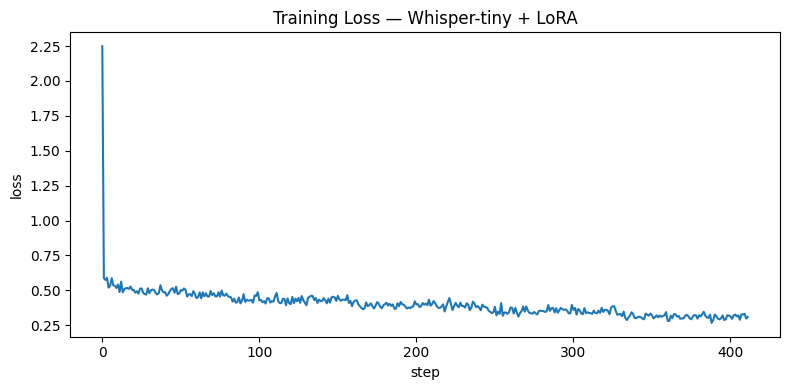

In [16]:
# ── 13. Evaluation after fine-tuning ─────────────────────────────────────────
eval_results = trainer.evaluate()
wer_lora     = eval_results['eval_wer']
print(f"LoRA WER (full eval set): {wer_lora:.4f}")

# Training loss curve
log_history = pd.DataFrame(trainer.state.log_history)
if 'loss' in log_history.columns:
    plt.figure(figsize=(8, 4))
    log_history.dropna(subset=['loss'])['loss'].plot()
    plt.title('Training Loss — Whisper-tiny + LoRA')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "whisper_tiny_lora_train_loss.png", dpi=100)
    plt.show()

  LoRA  [3-4] WER = 1.0169
  LoRA  [5-7] WER = 0.1558
  LoRA  [8-11] WER = 0.1683


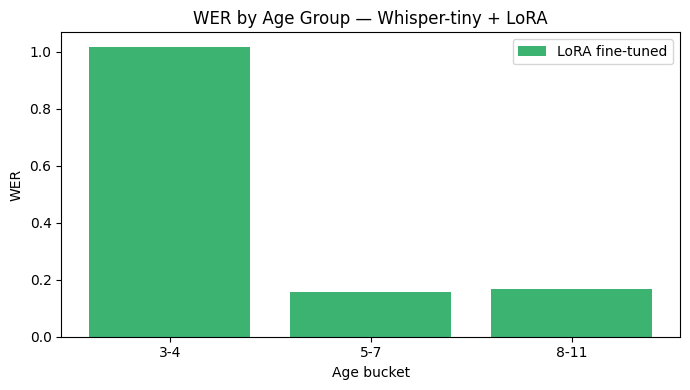

In [17]:
# ── 14. WER by age bucket ─────────────────────────────────────────────────────
model.eval()
age_wer_lora = {}
age_wer_zero = {}

for bucket in ['3-4', '5-7', '8-11']:
    bucket_eval = [d for d in eval_data if d['age_bucket'] == bucket]
    if not bucket_eval:
        continue
    preds_lora, preds_zero, refs = [], [], []
    for item in bucket_eval:
        audio = load_audio(item['audio_path'])
        preds_lora.append(transcribe(audio, model, processor))
        refs.append(item['orthographic_text'])

    age_wer_lora[bucket] = wer_score(refs, preds_lora)
    print(f"  LoRA  [{bucket}] WER = {age_wer_lora[bucket]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
x  = np.arange(len(age_wer_lora))
ax.bar(x, age_wer_lora.values(), color='mediumseagreen', label='LoRA fine-tuned')
ax.set_xticks(x)
ax.set_xticklabels(age_wer_lora.keys())
ax.set(xlabel='Age bucket', ylabel='WER',
       title='WER by Age Group — Whisper-tiny + LoRA')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_tiny_lora_wer_by_age.png", dpi=100)
plt.show()

In [ ]:
# ── 15. Zero-shot vs LoRA comparison ─────────────────────────────────────────
# Re-run zero-shot on same eval_data[:ZERO_SHOT_N] using the base model
# (LoRA adapters are disabled by temporarily merging with scale=0)
# Simplest approach: reload the base model without adapters for zero-shot eval

print("Computing per-age zero-shot WER for comparison...")

base_for_eval = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
base_for_eval.config.forced_decoder_ids   = forced_decoder_ids
base_for_eval.config.suppress_tokens      = []
base_for_eval.generation_config.language  = "english"
base_for_eval.generation_config.task      = "transcribe"
base_for_eval.generation_config.forced_decoder_ids = forced_decoder_ids
base_for_eval.eval()

age_wer_zero = {}
for bucket in ['3-4', '5-7', '8-11']:
    bucket_eval = [d for d in eval_data if d['age_bucket'] == bucket]
    if not bucket_eval:
        continue    
    preds, refs = [], []
    for item in bucket_eval:
        audio = load_audio(item['audio_path'])
        preds.append(transcribe(audio, base_for_eval, processor))
        refs.append(item['orthographic_text'])
    age_wer_zero[bucket] = wer_score(refs, preds)
    print(f"  Zero-shot [{bucket}] WER = {age_wer_zero[bucket]:.4f}")

del base_for_eval
torch.cuda.empty_cache()

Computing per-age zero-shot WER for comparison...


  Zero-shot [3-4] WER = 2.3444
  Zero-shot [5-7] WER = 1.6919
  Zero-shot [8-11] WER = 0.2961


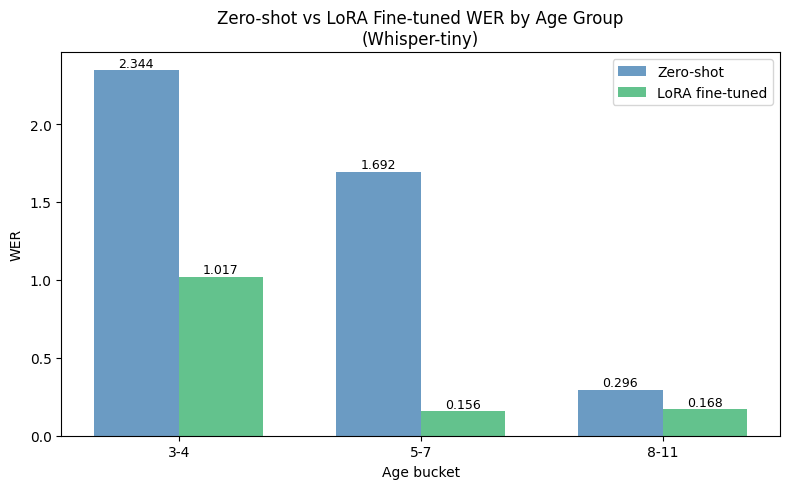


WER improvement (zero-shot → LoRA):
  [3-4]  2.3444 → 1.0169  (Δ = +1.3275, +56.6% relative)
  [5-7]  1.6919 → 0.1558  (Δ = +1.5361, +90.8% relative)
  [8-11]  0.2961 → 0.1683  (Δ = +0.1277, +43.1% relative)


In [19]:
# ── 16. Side-by-side bar chart ────────────────────────────────────────────────
buckets = list(age_wer_zero.keys())
zero_vals = [age_wer_zero[b] for b in buckets]
lora_vals = [age_wer_lora[b] for b in buckets]

x   = np.arange(len(buckets))
w   = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, zero_vals, w, label='Zero-shot',      color='steelblue',     alpha=0.8)
bars2 = ax.bar(x + w/2, lora_vals, w, label='LoRA fine-tuned', color='mediumseagreen', alpha=0.8)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set(xlabel='Age bucket', ylabel='WER',
       title='Zero-shot vs LoRA Fine-tuned WER by Age Group\n(Whisper-tiny)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_tiny_lora_comparison.png", dpi=100)
plt.show()

# Print WER improvement
print("\nWER improvement (zero-shot → LoRA):")
for b in buckets:
    delta = age_wer_zero[b] - age_wer_lora[b]
    rel   = delta / age_wer_zero[b] * 100
    print(f"  [{b}]  {age_wer_zero[b]:.4f} → {age_wer_lora[b]:.4f}  "
          f"(Δ = {delta:+.4f}, {rel:+.1f}% relative)")

In [20]:
# ── 17. Beam-search confidence (uncertainty proxy) ────────────────────────────
#
# Whisper returns per-step score tensors when output_scores=True.
# Token-level max-probability = confidence; token-level entropy = aleatoric proxy.

def beam_confidence(audio, model, processor, num_beams=5, max_new_tokens=225):
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)
    model.eval()
    with torch.no_grad():
        out = model.generate(
            input_features=input_features,
            num_beams               = num_beams,
            return_dict_in_generate = True,
            output_scores           = True,
            max_new_tokens          = max_new_tokens,
        )
    # out.scores: tuple of (batch, vocab) tensors, one per generated token
    scores = torch.stack(out.scores, dim=0).squeeze(1)      # (T_gen, vocab)
    probs  = torch.softmax(scores, dim=-1)
    token_conf    = probs.max(dim=-1).values                 # (T_gen,)
    token_entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)  # (T_gen,)
    transcription = processor.tokenizer.decode(
        out.sequences[0], skip_special_tokens=True
    )
    return {
        "transcription" : transcription,
        "mean_conf"     : token_conf.mean().item(),
        "mean_entropy"  : token_entropy.mean().item(),
        "token_conf"    : token_conf.cpu().numpy(),
        "token_entropy" : token_entropy.cpu().numpy(),
    }

The following generation flags are not valid and may be ignored: ['output_scores']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


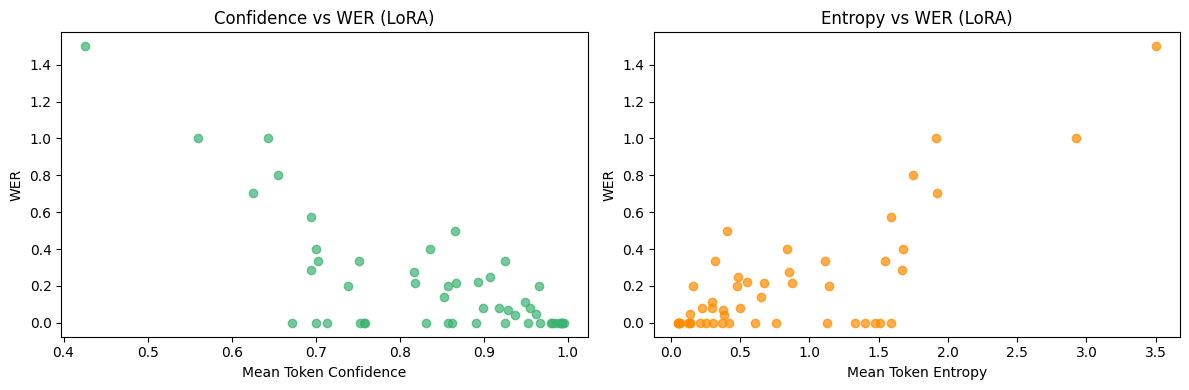

Pearson correlation with WER:
 mean_conf   -0.730
entropy      0.768
Name: wer, dtype: float64


In [21]:
# ── 18. Uncertainty vs WER ────────────────────────────────────────────────────
N_UNC = 50
unc_results = []
for item in random.sample(eval_data, N_UNC):
    audio = load_audio(item['audio_path'])
    b     = beam_confidence(audio, model, processor)
    wer_i = wer_score([item['orthographic_text']], [b['transcription']])
    unc_results.append({
        "reference"  : item['orthographic_text'],
        "prediction" : b['transcription'],
        "wer"        : wer_i,
        "mean_conf"  : b['mean_conf'],
        "entropy"    : b['mean_entropy'],
        "age_bucket" : item['age_bucket'],
    })

unc_df = pd.DataFrame(unc_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(unc_df['mean_conf'],  unc_df['wer'], alpha=0.7, color='mediumseagreen')
axes[0].set(xlabel='Mean Token Confidence', ylabel='WER',
            title='Confidence vs WER (LoRA)')
axes[1].scatter(unc_df['entropy'], unc_df['wer'], alpha=0.7, color='darkorange')
axes[1].set(xlabel='Mean Token Entropy', ylabel='WER',
            title='Entropy vs WER (LoRA)')
plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_tiny_lora_uncertainty.png", dpi=100)
plt.show()

corr = unc_df[['mean_conf', 'entropy', 'wer']].corr()['wer'].drop('wer')
print("Pearson correlation with WER:\n", corr.round(3))

In [22]:
# ── 19. Load adapter for inference (how to re-use saved weights) ──────────────
# Demonstrates the minimal footprint of LoRA: only adapter weights are stored.

def load_lora_model(adapter_dir, model_name=MODEL_NAME):
    """Re-load the base model and attach the saved LoRA adapter."""
    base = WhisperForConditionalGeneration.from_pretrained(model_name)
    base.config.forced_decoder_ids = forced_decoder_ids
    base.config.suppress_tokens    = []
    return PeftModel.from_pretrained(base, adapter_dir)

# Quick sanity-check: reload and transcribe one sample
reloaded = load_lora_model(OUTPUT_DIR).to(device).eval()
sample   = eval_data[0]
audio    = load_audio(sample['audio_path'])
hyp      = transcribe(audio, reloaded, processor)
print(f"Reference : {sample['orthographic_text']}")
print(f"Hypothesis: {hyp}")
del reloaded; torch.cuda.empty_cache()

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


Reference : it is the liquid i cant hear her um the water is a liquid
Hypothesis: it is planning the liquid um the water is a liquid


In [23]:
# ── 20. Parameter efficiency summary table ────────────────────────────────────
full_trainable = sum(p.numel()
                     for p in WhisperForConditionalGeneration
                     .from_pretrained(MODEL_NAME).parameters())

rows = [
    ("Whisper-tiny (zero-shot)",  full_trainable, 0,         wer_zero_shot),
    ("Whisper-tiny (full FT)",    full_trainable, full_trainable, float('nan')),
    (f"Whisper-tiny + LoRA r={LORA_R}", full_trainable, trainable, wer_lora),
]
summary = pd.DataFrame(rows,
    columns=["Model", "Total params", "Trainable params", "WER"])
summary["Trainable %"] = (summary["Trainable params"] / summary["Total params"] * 100).round(2)
print(summary.to_string(index=False))

                   Model  Total params  Trainable params      WER  Trainable %
Whisper-tiny (zero-shot)      37760640                 0 0.404470         0.00
  Whisper-tiny (full FT)      37760640          37760640      NaN       100.00
Whisper-tiny + LoRA r=16      37760640            294912 0.187645         0.78


In [24]:
# ── 21. Summary ───────────────────────────────────────────────────────────────
print("=" * 60)
print("SUMMARY — Whisper-tiny + LoRA")
print("=" * 60)
print(f"Base model         : {MODEL_NAME}")
print(f"LoRA rank          : {LORA_R}   alpha={LORA_ALPHA}")
print(f"Target modules     : {LORA_TARGET_MODULES}")
print(f"Trainable params   : {trainable:,}  ({100*trainable/total:.2f}% of total)")
print(f"Train samples      : {len(train_data):,}")
print(f"Eval  samples      : {len(eval_data):,}")
print(f"Epochs             : {NUM_EPOCHS}")
print(f"Zero-shot WER      : {wer_zero_shot:.4f}")
print(f"LoRA WER           : {wer_lora:.4f}")
improvement = (wer_zero_shot - wer_lora) / wer_zero_shot * 100
print(f"Relative WER Δ     : {improvement:+.1f}%")
print()
print("WER by age bucket:")
for b in buckets:
    print(f"  [{b}]  zero-shot={age_wer_zero[b]:.4f}  LoRA={age_wer_lora[b]:.4f}")

SUMMARY — Whisper-tiny + LoRA
Base model         : openai/whisper-tiny
LoRA rank          : 16   alpha=32
Target modules     : ['q_proj', 'v_proj']
Trainable params   : 294,912  (0.77% of total)
Train samples      : 65,337
Eval  samples      : 14,079
Epochs             : 5
Zero-shot WER      : 0.4045
LoRA WER           : 0.1876
Relative WER Δ     : +53.6%

WER by age bucket:
  [3-4]  zero-shot=2.3444  LoRA=1.0169
  [5-7]  zero-shot=1.6919  LoRA=0.1558
  [8-11]  zero-shot=0.2961  LoRA=0.1683
